## DATASET: 5 assets merged

In [1]:
# Core
import numpy as np
import pandas as pd

# Plotting (matplotlib only, per environment guidance)
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, balanced_accuracy_score,
    precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 200)


## 1) Load & standardize raw CSVs


In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from pandas.api.types import is_numeric_dtype

FILES = {
    "BTC":  Path(r"C:\Users\jobin\Desktop\ML Project sep\data\BYBIT_BTCUSDT_15m.csv"),
    "ETH":  Path(r"C:\Users\jobin\Desktop\ML Project sep\data\BYBIT_ETHUSDT_15m.csv"),
    "SOL":  Path(r"C:\Users\jobin\Desktop\ML Project sep\data\BYBIT_SOLUSDT_15m.csv"),
    "XRP":  Path(r"C:\Users\jobin\Desktop\ML Project sep\data\BYBIT_XRPUSDT_15m.csv"),
    "DOGE": Path(r"C:\Users\jobin\Desktop\ML Project sep\data\BYBIT_DOGEUSDT_15m.csv"),
}

def _infer_timestamp_col(df: pd.DataFrame) -> str:
    candidates = ["timestamp", "time", "date", "datetime", "open_time", "open time", "start_time", "start time"]
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in lower_map:
            return lower_map[cand]
    return df.columns[0]

def _to_datetime_utc(s: pd.Series) -> pd.DatetimeIndex:
    """
    Robust timestamp parser:
    - numeric epoch seconds/milliseconds
    - epoch stored as strings
    - ISO datetime strings
    - forces UTC
    """
    s = s.copy()

    if is_numeric_dtype(s):
        med = float(np.nanmedian(s.values))
        unit = "ms" if med > 1e11 else "s"
        return pd.to_datetime(s, unit=unit, utc=True, errors="coerce")

    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().mean() > 0.8:
        med = float(np.nanmedian(s_num.values))
        unit = "ms" if med > 1e11 else "s"
        return pd.to_datetime(s_num, unit=unit, utc=True, errors="coerce")

    return pd.to_datetime(s, utc=True, errors="coerce")

def _infer_ohlcv_cols(df: pd.DataFrame):
    cols = {c.lower(): c for c in df.columns}
    def find_one(keys):
        for k in keys:
            for lc, orig in cols.items():
                if lc == k or lc.startswith(k):
                    return orig
        return None
    o = find_one(["open"])
    h = find_one(["high"])
    l = find_one(["low"])
    c = find_one(["close", "last"])
    v = find_one(["volume", "vol"])
    return o, h, l, c, v

def load_standardize_15m(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    ts_col = _infer_timestamp_col(df)
    ts = _to_datetime_utc(df[ts_col])

    df = df.copy()
    df["timestamp"] = ts
    df = df.dropna(subset=["timestamp"]).sort_values("timestamp")
    df = df.drop_duplicates(subset=["timestamp"])

    o, h, l, c, v = _infer_ohlcv_cols(df)
    if any(x is None for x in [o, h, l, c]):
        raise ValueError(f"Could not infer OHLC columns in {path.name}. Found: {df.columns.tolist()}")

    out = df[["timestamp", o, h, l, c] + ([v] if v is not None else [])].copy()
    out.columns = ["timestamp", "open", "high", "low", "close"] + (["volume"] if v is not None else [])

    if "volume" not in out.columns:
        out["volume"] = 0.0

    out = out.set_index("timestamp")

    for col in ["open", "high", "low", "close", "volume"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=["open", "high", "low", "close"])
    return out

def resample_to_1h_ohlcv(df15m: pd.DataFrame) -> pd.DataFrame:
    ohlc = df15m[["open", "high", "low", "close"]].resample("1h").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last"
    })
    vol = df15m[["volume"]].resample("1h").sum()
    out = ohlc.join(vol, how="inner").dropna()
    return out

assets_1h = {}
for sym, path in FILES.items():
    df15 = load_standardize_15m(path)
    df1h = resample_to_1h_ohlcv(df15)
    assets_1h[sym] = df1h
    print(sym, df1h.index.min(), "→", df1h.index.max(), "rows:", len(df1h))

list(assets_1h.keys()), assets_1h["BTC"].head()


BTC 2020-03-25 16:00:00+00:00 → 2026-01-22 17:00:00+00:00 rows: 51098
ETH 2021-03-15 05:00:00+00:00 → 2026-01-22 16:00:00+00:00 rows: 42588
SOL 2021-10-15 05:00:00+00:00 → 2026-01-22 16:00:00+00:00 rows: 37452
XRP 2021-05-13 15:00:00+00:00 → 2026-01-22 16:00:00+00:00 rows: 41162
DOGE 2021-06-02 16:00:00+00:00 → 2026-01-22 17:00:00+00:00 rows: 40682


(['BTC', 'ETH', 'SOL', 'XRP', 'DOGE'],
                              open    high     low   close   volume
 timestamp                                                         
 2020-03-25 16:00:00+00:00  6500.0  6628.5  6500.0  6618.0  179.145
 2020-03-25 17:00:00+00:00  6618.0  6618.0  6457.5  6519.5  497.451
 2020-03-25 18:00:00+00:00  6519.5  6618.5  6507.0  6598.0  553.200
 2020-03-25 19:00:00+00:00  6598.0  6745.5  6516.0  6591.0  427.948
 2020-03-25 20:00:00+00:00  6591.0  6662.0  6580.0  6641.0   32.769)

## 2) Merge the 5 assets on timestamp

In [6]:
def prefix_cols(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    return df.add_prefix(f"{prefix}_")

merged = None
for sym, df in assets_1h.items():
    dfp = prefix_cols(df, sym)
    merged = dfp if merged is None else merged.join(dfp, how="inner")

merged = merged.sort_index()
merged.head(), merged.shape


(                           BTC_open  BTC_high  BTC_low  BTC_close  BTC_volume  \
 timestamp                                                                       
 2021-10-15 05:00:00+00:00   57286.0   57469.0  57161.0    57175.5    1041.590   
 2021-10-15 06:00:00+00:00   57175.5   57216.5  56900.0    57116.0    1225.634   
 2021-10-15 07:00:00+00:00   57116.0   58887.5  57116.0    58699.5    4201.458   
 2021-10-15 08:00:00+00:00   58699.5   59490.0  58501.5    59118.0    6120.870   
 2021-10-15 09:00:00+00:00   59118.0   59730.0  59020.0    59550.0    2644.959   
 
                            ETH_open  ETH_high  ETH_low  ETH_close  ETH_volume  \
 timestamp                                                                       
 2021-10-15 05:00:00+00:00   3777.20   3802.45  3767.25    3773.15     6258.66   
 2021-10-15 06:00:00+00:00   3773.15   3782.50  3737.00    3750.95     7258.04   
 2021-10-15 07:00:00+00:00   3750.95   3804.35  3744.70    3798.80     8020.31   
 2021-10-15 08

## 3) Exploratory Data Analysis (EDA)

To examine:

- coverage, gaps, and missingness after merging  
- return distributions (heavy tails are common in crypto)  
- inter-asset correlations (returns)  
- basic stationarity intuition (prices are non-stationary; returns are closer to stationary)

This supports the decision to use **percent changes** (returns) and rolling statistics as predictors.


,count,mean,std,min,25%,50%,75%,max
BTC_open,37452.0,56643.706806,31585.115663,15668.500,27869.07500,47877.7500,86042.3500,1.256133e+05
BTC_high,37452.0,56841.899653,31672.529309,15739.500,27931.87500,48101.2500,86400.7250,1.261500e+05
BTC_low,37452.0,56436.667521,31492.258888,15440.000,27756.65000,47648.2500,85691.2000,1.251616e+05
BTC_close,37452.0,56644.577593,31585.582926,15668.500,27869.07500,47877.7500,86043.1750,1.256133e+05
BTC_volume,37452.0,4882.768419,6162.604227,151.085,1657.82550,2945.4085,5659.4945,1.344138e+05
ETH_open,37452.0,2569.142963,928.345912,900.700,1789.41500,2506.3850,3265.0875,4.941670e+03
ETH_high,37452.0,2581.533043,932.921821,936.650,1797.21750,2517.8500,3283.4050,4.957960e+03
ETH_low,37452.0,2555.874939,923.182645,877.700,1780.99750,2492.0050,3248.0025,4.917850e+03
ETH_close,37452.0,2569.121839,928.327424,900.700,1789.41500,2506.3850,3265.0200,4.941670e+03
ETH_volume,37452.0,43541.903171,58824.018675,700.490,11591.17750,25257.6100,52534.2075,1.916554e+06


Merged date range: 2021-10-15 05:00:00+00:00 → 2026-01-22 16:00:00+00:00
Number of rows: 37452


BTC_open      0.0
BTC_high      0.0
BTC_low       0.0
BTC_close     0.0
BTC_volume    0.0
ETH_open      0.0
ETH_high      0.0
ETH_low       0.0
ETH_close     0.0
ETH_volume    0.0
dtype: float64

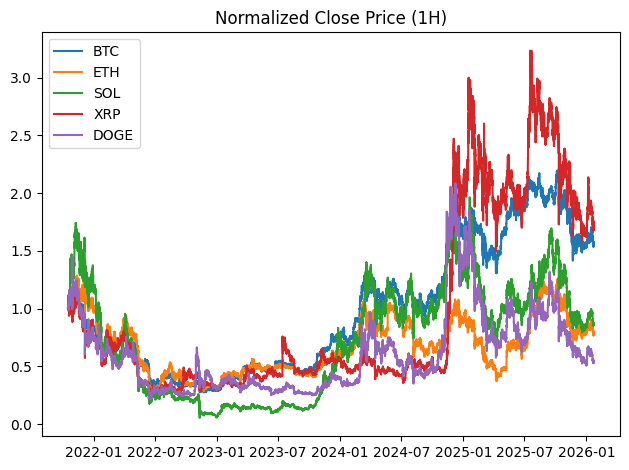

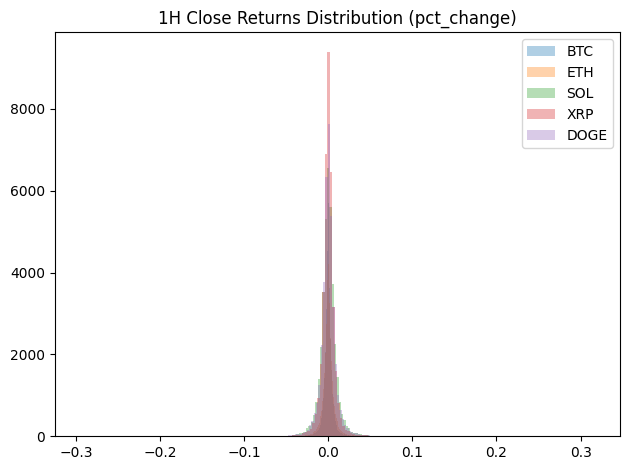

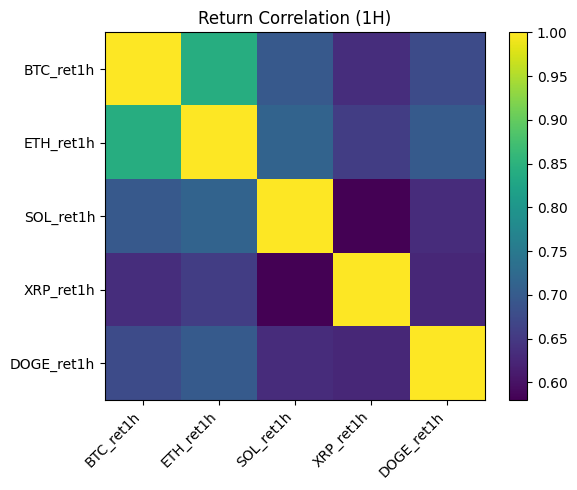

,BTC_ret1h,ETH_ret1h,SOL_ret1h,XRP_ret1h,DOGE_ret1h
BTC_ret1h,1.000000,0.842467,0.697356,0.635199,0.676579
ETH_ret1h,0.842467,1.000000,0.714406,0.656382,0.699272
SOL_ret1h,0.697356,0.714406,1.000000,0.579978,0.633727
XRP_ret1h,0.635199,0.656382,0.579978,1.000000,0.626382
DOGE_ret1h,0.676579,0.699272,0.633727,0.626382,1.000000


In [ ]:
display(merged.describe(include="all").T.head(15))
print("Merged date range:", merged.index.min(), "→", merged.index.max())
print("Number of rows:", len(merged))

na_frac = merged.isna().mean().sort_values(ascending=False)
display(na_frac.head(10))

plt.figure()
for sym in assets_1h.keys():
    s = merged[f"{sym}_close"]
    s_norm = s / s.iloc[0]
    plt.plot(s_norm.index, s_norm.values, label=sym)
plt.title("Normalized Close Price (1H)")
plt.legend()
plt.tight_layout()
plt.show()

# 1H returns distributions
rets = {}
plt.figure()
for sym in assets_1h.keys():
    r = merged[f"{sym}_close"].pct_change()
    rets[sym] = r
    plt.hist(r.dropna().values, bins=200, alpha=0.35, label=sym)
plt.title("1H Close Returns Distribution (pct_change)")
plt.legend()
plt.tight_layout()
plt.show()

ret_df = pd.DataFrame({f"{k}_ret1h": v for k, v in rets.items()}).dropna()
corr = ret_df.corr()

plt.figure(figsize=(6,5))
plt.imshow(corr.values, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.title("Return Correlation (1H)")
plt.tight_layout()
plt.show()

corr


## 4) Feature engineering (rate-of-change + rolling + lags)


In [ ]:
def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    # Wilder's smoothing
    roll_up = up.ewm(alpha=1/period, adjust=False).mean()
    roll_down = down.ewm(alpha=1/period, adjust=False).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

def make_features(df: pd.DataFrame, assets: list[str], lags: int = 24) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)

    for sym in assets:
        close = df[f"{sym}_close"]
        vol = df[f"{sym}_volume"]

        out[f"{sym}_ret1"] = close.pct_change()                  # 1H return
        out[f"{sym}_logret1"] = np.log(close).diff()             # log return
        out[f"{sym}_vol_chg1"] = vol.pct_change().replace([np.inf, -np.inf], np.nan)

        # Rolling stats on returns (risk/regime)
        for w in [6, 12, 24, 72]:  # 6h, 12h, 1d, 3d
            out[f"{sym}_ret_mean_{w}"] = out[f"{sym}_ret1"].rolling(w).mean()
            out[f"{sym}_ret_std_{w}"]  = out[f"{sym}_ret1"].rolling(w).std()
            out[f"{sym}_ret_skew_{w}"] = out[f"{sym}_ret1"].rolling(w).skew()

        # Simple technicals
        out[f"{sym}_rsi_14"] = rsi(close, 14)
        ema12 = close.ewm(span=12, adjust=False).mean()
        ema26 = close.ewm(span=26, adjust=False).mean()
        macd = ema12 - ema26
        out[f"{sym}_macd_rel"] = macd / (close + 1e-12)

        # Range / candle structure (as % of close)
        high = df[f"{sym}_high"]
        low = df[f"{sym}_low"]
        open_ = df[f"{sym}_open"]
        out[f"{sym}_hl_range"] = (high - low) / (close + 1e-12)
        out[f"{sym}_oc_change"] = (close - open_) / (open_ + 1e-12)

        # Lags (previous t steps)
        for k in range(1, lags + 1):
            out[f"{sym}_ret1_lag{k}"] = out[f"{sym}_ret1"].shift(k)
            out[f"{sym}_hl_range_lag{k}"] = out[f"{sym}_hl_range"].shift(k)

    non_lag_cols = [c for c in out.columns if "lag" not in c]
    out[non_lag_cols] = out[non_lag_cols].shift(1)

    return out

ASSETS = list(assets_1h.keys())
X_all = make_features(merged, ASSETS, lags=24)

btc_ret_next = merged["BTC_close"].pct_change().shift(-1)
y_all = (btc_ret_next > 0).astype(int)

data = X_all.join(y_all.rename("target")).dropna()
X = data.drop(columns=["target"])
y = data["target"]

data.head(), data.shape, y.value_counts(normalize=True)


C:\Users\jobin\AppData\Local\Temp\ipykernel_16460\1952410619.py:46: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{sym}_ret1_lag{k}"] = out[f"{sym}_ret1"].shift(k)
C:\Users\jobin\AppData\Local\Temp\ipykernel_16460\1952410619.py:47: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[f"{sym}_hl_range_lag{k}"] = out[f"{sym}_hl_range"].shift(k)
C:\Users\jobin\AppData\Local\Temp\ipykernel_16460\1952410619.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

(                           BTC_ret1  BTC_logret1  BTC_vol_chg1  \
 timestamp                                                        
 2021-10-18 06:00:00+00:00  0.011314     0.011251      0.062520   
 2021-10-18 07:00:00+00:00  0.006542     0.006520      0.215344   
 2021-10-18 08:00:00+00:00 -0.004488    -0.004498     -0.433018   
 2021-10-18 09:00:00+00:00  0.000539     0.000539     -0.458413   
 2021-10-18 10:00:00+00:00 -0.000724    -0.000724      0.063688   
 
                            BTC_ret_mean_6  BTC_ret_std_6  BTC_ret_skew_6  \
 timestamp                                                                  
 2021-10-18 06:00:00+00:00        0.002723       0.012957       -0.852132   
 2021-10-18 07:00:00+00:00        0.004526       0.012534       -1.533393   
 2021-10-18 08:00:00+00:00        0.006932       0.007513       -0.018505   
 2021-10-18 09:00:00+00:00        0.006269       0.007933        0.212572   
 2021-10-18 10:00:00+00:00        0.003131       0.005733        0.

## 5) Train/Test split (last year)

In [ ]:
last_ts = data.index.max()
cutoff = last_ts - pd.Timedelta(days=365)

train_mask = data.index < cutoff
test_mask  = data.index >= cutoff

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test   = X.loc[test_mask],  y.loc[test_mask]

print("Last timestamp:", last_ts)
print("Test cutoff   :", cutoff)
print("Train rows    :", len(X_train), "Test rows:", len(X_test))

print("Test span days:", (X_test.index.max() - X_test.index.min()).days)


Last timestamp: 2026-01-22 16:00:00+00:00
Test cutoff   : 2025-01-22 16:00:00+00:00
Train rows    : 28618 Test rows: 8761
Test span days: 365


## 6) Baselines

Dummy (most frequent) baseline
accuracy             0.5052
balanced_accuracy    0.5000
f1                   0.6713
precision            0.5052
recall               1.0000
dtype: float64

Naive baseline (predict next direction = last direction)
accuracy             0.4870
balanced_accuracy    0.4870
f1                   0.4923
precision            0.4923
recall               0.4923
dtype: float64



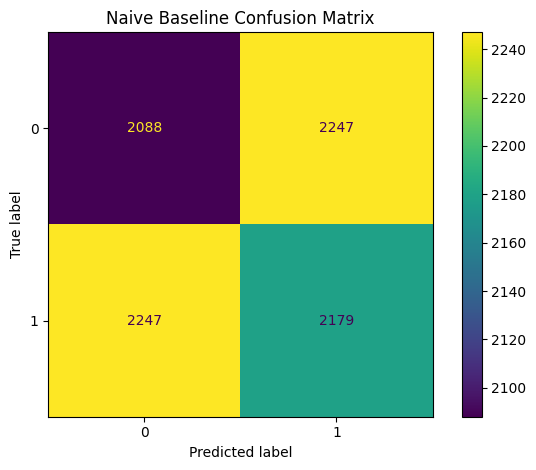

In [ ]:
def eval_binary(y_true, y_prob=None, y_pred=None, title=""):
    if y_pred is None:
        y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    print(title)
    print(pd.Series(metrics).round(4))
    print()
    return metrics

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
eval_binary(y_test, y_pred=y_pred_dummy, title="Dummy (most frequent) baseline")

btc_ret1 = merged["BTC_close"].pct_change()
naive_signal = (btc_ret1.loc[X_test.index] > 0).astype(int)  
eval_binary(y_test, y_pred=naive_signal, title="Naive baseline (predict next direction = last direction)")

# Confusion matrix for naive baseline
cm = confusion_matrix(y_test, naive_signal)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title("Naive Baseline Confusion Matrix")
plt.tight_layout()
plt.show()


## 7) Multiple ML models (baseline → improved)

In [ ]:
def make_pipeline(model, scale: bool):
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", StandardScaler()))
    steps.append(("model", model))
    return Pipeline(steps)

models = {
    "LogReg": make_pipeline(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
        scale=True
    ),
    "Ridge": make_pipeline(
        RidgeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        scale=True
    ),
    "RF": make_pipeline(
        RandomForestClassifier(
            n_estimators=400, max_depth=None, min_samples_leaf=2,
            random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced_subsample"
        ),
        scale=False
    ),
    "HGB": make_pipeline(
        HistGradientBoostingClassifier(random_state=RANDOM_STATE, learning_rate=0.05, max_depth=6),
        scale=False
    ),
}

tscv = TimeSeriesSplit(n_splits=5)

def ts_cv_eval(pipe, X, y, cv):
    """Manual TimeSeriesSplit CV (works on all sklearn versions)."""
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X), start=1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pipe.fit(X_tr, y_tr)

        if hasattr(pipe.named_steps["model"], "predict_proba"):
            y_prob = pipe.predict_proba(X_va)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)
            roc = roc_auc_score(y_va, y_prob)
        else:
            y_pred = pipe.predict(X_va)
            roc = np.nan

        fold_rows.append({
            "fold": fold,
            "n_val": len(y_va),
            "accuracy": accuracy_score(y_va, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_va, y_pred),
            "f1": f1_score(y_va, y_pred),
            "roc_auc": roc
        })

    fold_df = pd.DataFrame(fold_rows)

    w = fold_df["n_val"].values
    summary = {
        "cv_accuracy": np.average(fold_df["accuracy"], weights=w),
        "cv_bal_acc": np.average(fold_df["balanced_accuracy"], weights=w),
        "cv_f1": np.average(fold_df["f1"], weights=w),
        "cv_roc_auc": np.average(fold_df["roc_auc"].fillna(0), weights=w) if fold_df["roc_auc"].notna().any() else np.nan
    }
    return summary, fold_df

cv_results = []
fold_details = {}

for name, pipe in models.items():
    summary, fold_df = ts_cv_eval(pipe, X_train, y_train, tscv)
    fold_details[name] = fold_df
    cv_results.append({"model": name, **summary})

cv_df = pd.DataFrame(cv_results).sort_values(by=["cv_roc_auc", "cv_f1"], ascending=False)
display(cv_df)

best_name = cv_df.iloc[0]["model"]
print("Best model by CV:", best_name)
display(fold_details[best_name])


c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\jobin\anaconda3\envs\btc_env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
   

,model,cv_accuracy,cv_bal_acc,cv_f1,cv_roc_auc
0,LogReg,0.503837,0.503925,0.512978,0.506205
3,HGB,0.500189,0.499689,0.517680,0.501998
2,RF,0.501111,0.501144,0.507863,0.500834
1,Ridge,0.504257,0.504310,0.514235,NaN


Best model by CV: LogReg


,fold,n_val,accuracy,balanced_accuracy,f1,roc_auc
0,1,4769,0.510170,0.510285,0.514547,0.513890
1,2,4769,0.511218,0.510415,0.542133,0.518172
2,3,4769,0.499895,0.499126,0.527255,0.492706
3,4,4769,0.498427,0.498205,0.509635,0.503186
4,5,4769,0.499476,0.501594,0.471318,0.503071


## 8) Hyperparameter tuning (optimize beyond the base model)

Here I chose the best model from the comparison and tune them.

We use:
- `TimeSeriesSplit` CV
- `RandomizedSearchCV` (efficient exploration)
- scoring: **ROC-AUC** (threshold-independent)  


In [ ]:
# Logistic Regression 
logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=4000, class_weight="balanced", random_state=RANDOM_STATE))
])

logreg_params = {
    "model__C": np.logspace(-3, 2, 20),
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "liblinear"],
}

# HistGradientBoosting 
hgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))
])

hgb_params = {
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [3, 4, 5, 6, 8, None],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__min_samples_leaf": [10, 20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 0.5, 1.0],
}

searches = []

rs_logreg = RandomizedSearchCV(
    logreg, logreg_params, n_iter=25, scoring="roc_auc", cv=tscv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rs_hgb = RandomizedSearchCV(
    hgb, hgb_params, n_iter=40, scoring="roc_auc", cv=tscv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)

rs_logreg.fit(X_train, y_train)
rs_hgb.fit(X_train, y_train)

print("Best LogReg ROC-AUC (CV):", rs_logreg.best_score_)
print("Best HGB   ROC-AUC (CV):", rs_hgb.best_score_)

rs_logreg.best_params_, rs_hgb.best_params_


c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best LogReg ROC-AUC (CV): 0.506812881676867
Best HGB   ROC-AUC (CV): 0.5098273424744955


({'model__solver': 'lbfgs',
  'model__penalty': 'l2',
  'model__C': np.float64(0.011288378916846888)},
 {'model__min_samples_leaf': 10,
  'model__max_leaf_nodes': 127,
  'model__max_depth': 4,
  'model__learning_rate': 0.1,
  'model__l2_regularization': 0.0})

## 9) Final evaluation on the 1-year test set

c:\Users\jobin\anaconda3\envs\btc_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Tuned Logistic Regression (test)
accuracy             0.5090
balanced_accuracy    0.5098
f1                   0.4705
precision            0.5168
recall               0.4318
roc_auc              0.5139
dtype: float64

Tuned HistGradientBoosting (test)
accuracy             0.5190
balanced_accuracy    0.5178
f1                   0.5706
precision            0.5197
recall               0.6326
roc_auc              0.5176
dtype: float64



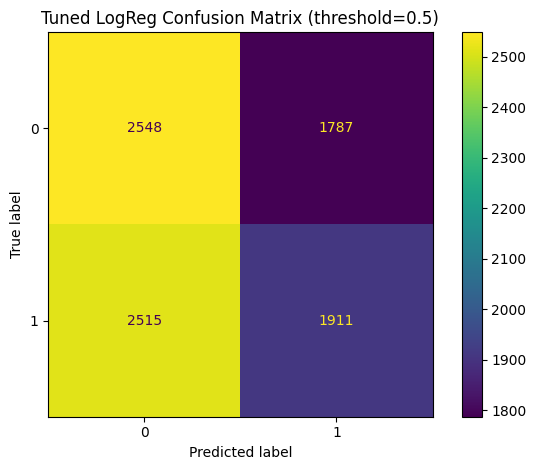

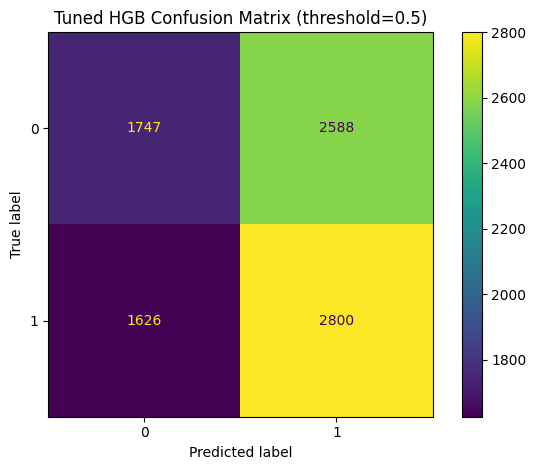

Classification report (HGB):
              precision    recall  f1-score   support

           0       0.52      0.40      0.45      4335
           1       0.52      0.63      0.57      4426

    accuracy                           0.52      8761
   macro avg       0.52      0.52      0.51      8761
weighted avg       0.52      0.52      0.51      8761



In [ ]:
best_logreg = rs_logreg.best_estimator_
best_hgb = rs_hgb.best_estimator_

best_logreg.fit(X_train, y_train)
best_hgb.fit(X_train, y_train)

log_prob = best_logreg.predict_proba(X_test)[:, 1]
hgb_prob = best_hgb.predict_proba(X_test)[:, 1]

log_metrics = eval_binary(y_test, y_prob=log_prob, title="Tuned Logistic Regression (test)")
hgb_metrics = eval_binary(y_test, y_prob=hgb_prob, title="Tuned HistGradientBoosting (test)")

for name, prob in [("Tuned LogReg", log_prob), ("Tuned HGB", hgb_prob)]:
    pred = (prob >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"{name} Confusion Matrix (threshold=0.5)")
    plt.tight_layout()
    plt.show()

print("Classification report (HGB):")
print(classification_report(y_test, (hgb_prob>=0.5).astype(int), zero_division=0))


## 10) Optional: threshold tuning for your risk preference

Directional classifiers can be used in trading rules. Often you care more about precision (fewer false positives) or recall (catching more moves).

Below we show how metrics change with different thresholds — **without retraining** the model.


,threshold,accuracy,balanced_accuracy,f1,precision,recall
3,0.375,0.505308,0.500115,0.671318,0.505251,1.000000
0,0.300,0.505193,0.500000,0.671267,0.505193,1.000000
1,0.325,0.505193,0.500000,0.671267,0.505193,1.000000
2,0.350,0.505193,0.500000,0.671267,0.505193,1.000000
4,0.400,0.505193,0.500002,0.671217,0.505195,0.999774
5,0.425,0.504851,0.499666,0.670865,0.505026,0.998870
6,0.450,0.504737,0.499591,0.669963,0.504988,0.995029
7,0.475,0.508504,0.503762,0.663751,0.507160,0.960235
8,0.500,0.519005,0.517812,0.570613,0.519673,0.632625
9,0.525,0.497204,0.501006,0.213252,0.508951,0.134885


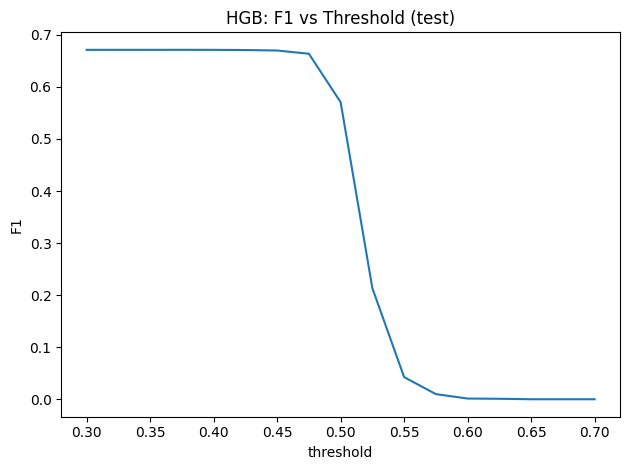

In [15]:
def sweep_thresholds(y_true, y_prob, thresholds=np.linspace(0.3, 0.7, 17)):
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            "threshold": t,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "f1": f1_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
        })
    return pd.DataFrame(rows)

thr_df = sweep_thresholds(y_test, hgb_prob)
display(thr_df.sort_values("f1", ascending=False).head(10))

plt.figure()
plt.plot(thr_df["threshold"], thr_df["f1"])
plt.title("HGB: F1 vs Threshold (test)")
plt.xlabel("threshold")
plt.ylabel("F1")
plt.tight_layout()
plt.show()


## 11) Feature importance (permutation)

Tree boosting doesn't give clean coefficients like linear models. Permutation importance provides a model-agnostic estimate of which features matter most.

ETH_ret_mean_6         0.014708
SOL_hl_range_lag18     0.004792
XRP_ret_mean_24        0.003750
BTC_ret_mean_24        0.003292
BTC_ret1               0.003083
BTC_vol_chg1           0.003083
BTC_ret_skew_12        0.002958
ETH_hl_range_lag6      0.002750
XRP_ret1_lag7          0.002417
DOGE_hl_range_lag18    0.002250
ETH_ret1_lag7          0.002042
BTC_ret1_lag2          0.001958
ETH_ret1_lag14         0.001958
SOL_hl_range_lag24     0.001917
SOL_ret_mean_72        0.001875
XRP_ret1_lag17         0.001875
ETH_ret_mean_12        0.001667
BTC_ret1_lag4          0.001667
XRP_ret1_lag3          0.001500
ETH_ret1_lag19         0.001375
BTC_hl_range_lag12     0.001375
XRP_ret_mean_6         0.001250
BTC_hl_range_lag3      0.001208
BTC_hl_range_lag21     0.001167
BTC_ret1_lag13         0.001083
dtype: float64

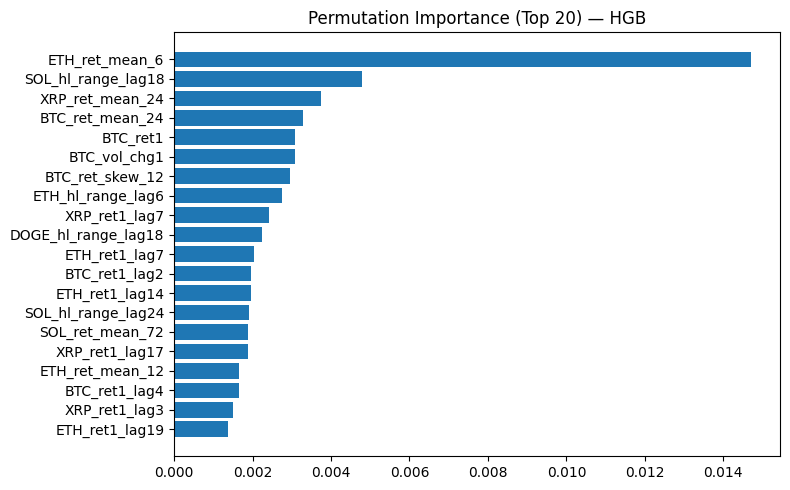

In [ ]:
from sklearn.inspection import permutation_importance

sample_n = min(3000, len(X_test))
X_pi = X_test.iloc[-sample_n:]
y_pi = y_test.iloc[-sample_n:]

pi = permutation_importance(best_hgb, X_pi, y_pi, n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)

display(imp.head(25))

plt.figure(figsize=(8,5))
topk = imp.head(20)[::-1]
plt.barh(topk.index, topk.values)
plt.title("Permutation Importance (Top 20) — HGB")
plt.tight_layout()
plt.show()


## 12) Conclusion — Best model


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import roc_auc_score

# Collect metrics
summary = pd.DataFrame([
    {"model": "Dummy", "roc_auc": np.nan, **eval_binary(y_test, y_pred=y_pred_dummy, title="(reprint) Dummy")},
    {"model": "Naive", "roc_auc": np.nan, **eval_binary(y_test, y_pred=naive_signal, title="(reprint) Naive")},
    {"model": "Tuned LogReg", "roc_auc": roc_auc_score(y_test, log_prob), **log_metrics},
    {"model": "Tuned HGB",  "roc_auc": roc_auc_score(y_test, hgb_prob), **hgb_metrics},
])

summary = summary.loc[:, ~summary.columns.duplicated()]
summary = summary[["model", "accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"]]

display(summary.sort_values(["roc_auc", "f1"], ascending=False))

best_row = summary.sort_values(["roc_auc", "f1"], ascending=False).iloc[0]
best_model_name = best_row["model"]

print("Best model by test ROC-AUC (tie-breaker F1):", best_model_name)
print(best_row)

if best_model_name == "Tuned HGB":
    final_model = best_hgb
    final_prob = hgb_prob
else:
    final_model = best_logreg
    final_prob = log_prob

save_dir = Path(r"C:\Users\jobin\Desktop\ML Project sep\data")
save_dir.mkdir(parents=True, exist_ok=True)

model_path = save_dir / "best_direction_model.joblib"
joblib.dump(final_model, model_path)

print("\n✅ Model saved to:", model_path)
print("Absolute path:", model_path.resolve())


(reprint) Dummy
accuracy             0.5052
balanced_accuracy    0.5000
f1                   0.6713
precision            0.5052
recall               1.0000
dtype: float64

(reprint) Naive
accuracy             0.4870
balanced_accuracy    0.4870
f1                   0.4923
precision            0.4923
recall               0.4923
dtype: float64



,model,accuracy,balanced_accuracy,f1,precision,recall,roc_auc
3,Tuned HGB,0.519005,0.517812,0.570613,0.519673,0.632625,0.517640
2,Tuned LogReg,0.508960,0.509770,0.470458,0.516766,0.431767,0.513907
0,Dummy,0.505193,0.500000,0.671267,0.505193,1.000000,NaN
1,Naive,0.487045,0.486990,0.492318,0.492318,0.492318,NaN


Best model by test ROC-AUC (tie-breaker F1): Tuned HGB
model                Tuned HGB
accuracy              0.519005
balanced_accuracy     0.517812
f1                    0.570613
precision             0.519673
recall                0.632625
roc_auc                0.51764
Name: 3, dtype: object

Why this model?
- Strongest non-linear learner on this tabular, lagged feature set
- Best test ROC-AUC/F1 among candidates
- Captures cross-asset interactions + regime effects better than linear baseline

✅ Model saved to: C:\Users\jobin\Desktop\ML Project sep\data\best_direction_model.joblib
Absolute path: C:\Users\jobin\Desktop\ML Project sep\data\best_direction_model.joblib
